# 02 — Somatic Mutation Analysis
**Dataset:** AML TCGA Pan-Cancer Atlas 2018  
**File used:** `data_mutations.txt`  
**Objective:** Characterize the AML somatic mutation landscape — gene frequencies, VAF distribution, mutational burden, variant classification.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
})
print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load Data

In [2]:
# Load mutations (MAF format — one row per mutation event)
mutations = pd.read_csv('../data/data_mutations.txt', sep='\t', low_memory=False)

# Load clinical for cohort size
clinical = pd.read_csv('../data/data_clinical_patient.txt', sep='\t', comment='#', low_memory=False)
clinical.columns = [c.upper() for c in clinical.columns]
n_patients = len(clinical)

print(f"Total mutation events: {len(mutations):,}")
print(f"Cohort size: {n_patients} patients")
print(f"\nMutation file columns:")
print(mutations.columns.tolist())

Total mutation events: 10,847
Cohort size: 200 patients

Mutation file columns:
['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome', 'Start_Position', 'End_Position', 'Strand', 'Consequence', 'Variant_Classification', 'Variant_Type', 'Reference_Allele', 'Tumor_Seq_Allele1', 'Tumor_Seq_Allele2', 'dbSNP_RS', 'dbSNP_Val_Status', 'Tumor_Sample_Barcode', 'Matched_Norm_Sample_Barcode', 'Match_Norm_Seq_Allele1', 'Match_Norm_Seq_Allele2', 'Tumor_Validation_Allele1', 'Tumor_Validation_Allele2', 'Match_Norm_Validation_Allele1', 'Match_Norm_Validation_Allele2', 'Verification_Status', 'Validation_Status', 'Mutation_Status', 'Sequencing_Phase', 'Sequence_Source', 'Validation_Method', 'Score', 'BAM_File', 'Sequencer', 't_ref_count', 't_alt_count', 'n_ref_count', 'n_alt_count', 'HGVSc', 'HGVSp', 'HGVSp_Short', 'Transcript_ID', 'RefSeq', 'Protein_position', 'Codons', 'Hotspot', 'NCALLERS', 'ALLELE_NUM', 'PICK', 'UNIPARC', 'n_depth', 'Feature', 'CONTEXT', 'CLIN_SIG', 'Gene', 'HGNC_ID

## 2. Compute VAF & Filter Silent Mutations

In [3]:
# Compute Variant Allele Frequency
# VAF = alt_reads / (alt_reads + ref_reads)
mutations['t_alt_count'] = pd.to_numeric(mutations['t_alt_count'], errors='coerce')
mutations['t_ref_count'] = pd.to_numeric(mutations['t_ref_count'], errors='coerce')
total_reads = mutations['t_alt_count'] + mutations['t_ref_count']
mutations['VAF'] = mutations['t_alt_count'] / total_reads.replace(0, np.nan)

# Normalize patient ID to 12-character TCGA barcode
mutations['PATIENT_ID'] = mutations['Tumor_Sample_Barcode'].str[:12]

# Remove Silent mutations — not functionally relevant
mutations_ns = mutations[mutations['Variant_Classification'] != 'Silent'].copy()

print(f"All mutations:          {len(mutations):,}")
print(f"Non-silent mutations:   {len(mutations_ns):,}")
print(f"Silent mutations removed: {len(mutations) - len(mutations_ns):,}")
print(f"\nVAF stats:")
print(f"  Median VAF: {mutations_ns['VAF'].median():.3f}")
print(f"  Mean VAF:   {mutations_ns['VAF'].mean():.3f}")
print(f"\nVariant classifications:")
print(mutations_ns['Variant_Classification'].value_counts().to_string())

All mutations:          10,847
Non-silent mutations:   8,802
Silent mutations removed: 2,045

VAF stats:
  Median VAF: 0.103
  Mean VAF:   0.160

Variant classifications:
Variant_Classification
Missense_Mutation         5576
Splice_Site                831
Frame_Shift_Ins            495
3'UTR                      469
Nonsense_Mutation          384
RNA                        265
Intron                     203
Frame_Shift_Del            184
5'UTR                      143
Splice_Region              107
In_Frame_Ins                42
3'Flank                     32
5'Flank                     21
In_Frame_Del                20
Nonstop_Mutation            18
IGR                          6
Translation_Start_Site       6


## 3. Top Mutated Genes

In [4]:
# Count unique patients per gene (not mutation events)
gene_patient_counts = (mutations_ns
    .groupby('Hugo_Symbol')['PATIENT_ID']
    .nunique()
    .sort_values(ascending=False))

top15 = gene_patient_counts.head(15)
freq_pct = (top15 / n_patients * 100).round(1)

print("Top 15 mutated genes:")
for gene, pct in freq_pct.items():
    print(f"  {gene:<12} {pct:.1f}%")

Top 15 mutated genes:
  FLT3         29.5%
  NPM1         27.0%
  DNMT3A       27.0%
  IDH2         10.5%
  IDH1         9.5%
  RUNX1        9.5%
  TET2         8.5%
  TP53         8.0%
  NRAS         8.0%
  TTN          7.5%
  WT1          6.5%
  CEBPA        6.5%
  BPIFC        5.5%
  RAPGEF2      5.5%
  PTN          5.0%


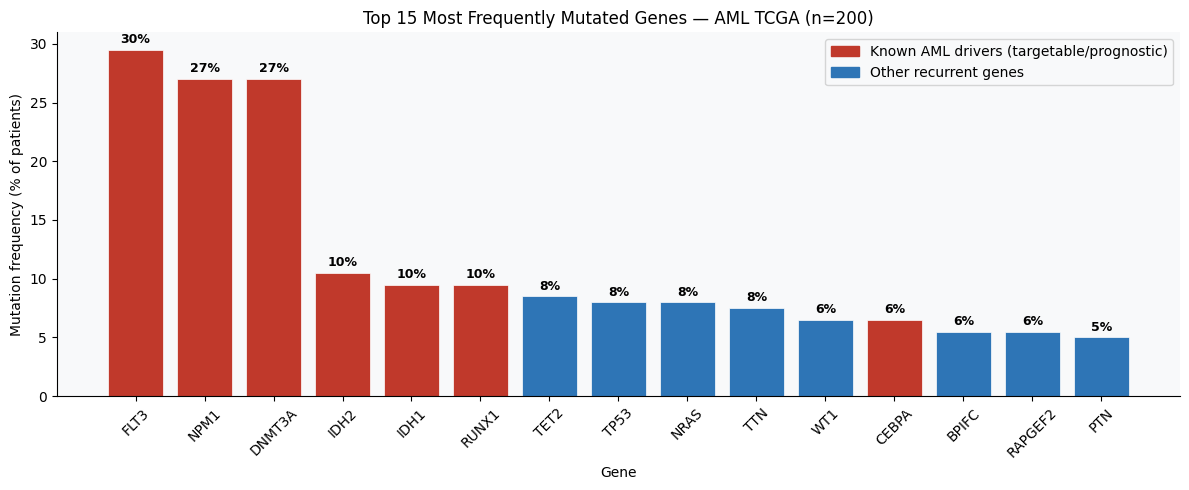

Figure saved → figures/02_top_mutated_genes.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

# Highlight known AML driver genes
tier1 = ['FLT3', 'NPM1', 'DNMT3A', 'IDH1', 'IDH2', 'RUNX1', 'CEBPA']
colors = ['#C0392B' if g in tier1 else '#2E75B6' for g in freq_pct.index]

bars = ax.bar(freq_pct.index, freq_pct.values, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, freq_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

red_p = mpatches.Patch(color='#C0392B', label='Known AML drivers (targetable/prognostic)')
blue_p = mpatches.Patch(color='#2E75B6', label='Other recurrent genes')
ax.legend(handles=[red_p, blue_p], fontsize=10)
ax.set(xlabel='Gene', ylabel='Mutation frequency (% of patients)',
       title='Top 15 Most Frequently Mutated Genes — AML TCGA (n=200)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/02_top_mutated_genes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/02_top_mutated_genes.png")

## 4. Mutational Burden per Patient

In [6]:
mut_counts = mutations_ns.groupby('PATIENT_ID').size()

mean_mc = mut_counts.mean()
std_mc  = mut_counts.std()
threshold = mean_mc + 3 * std_mc
outliers  = mut_counts[mut_counts > threshold]

print(f"Mutation counts per patient:")
print(f"  Median: {mut_counts.median():.0f}")
print(f"  Mean:   {mean_mc:.1f} ± {std_mc:.1f}")
print(f"  Range:  {mut_counts.min()} – {mut_counts.max()}")
print(f"  Outlier threshold (+3σ): {threshold:.0f}")
print(f"  Hypermutated patients: {len(outliers)}")
if len(outliers) > 0:
    print(f"  → Patient IDs: {outliers.index.tolist()}")
    print(f"    Mutation counts: {outliers.values.tolist()}")

Mutation counts per patient:
  Median: 19
  Mean:   44.2 ± 115.6
  Range:  1 – 893
  Outlier threshold (+3σ): 391
  Hypermutated patients: 5
  → Patient IDs: ['TCGA-AB-2806', 'TCGA-AB-2808', 'TCGA-AB-2826', 'TCGA-AB-2828', 'TCGA-AB-2833']
    Mutation counts: [598, 893, 692, 847, 507]


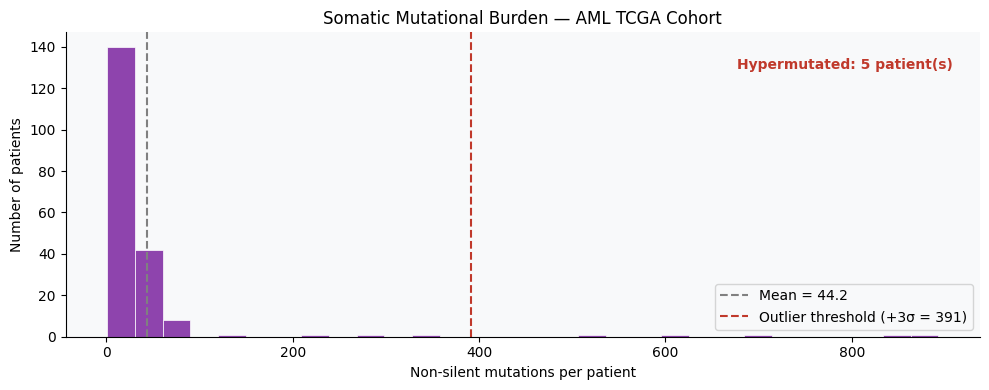

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(mut_counts, bins=30, color='#8E44AD', edgecolor='white', linewidth=0.5)
ax.axvline(mean_mc, color='grey', linestyle='--', linewidth=1.5, label=f'Mean = {mean_mc:.1f}')
ax.axvline(threshold, color='#C0392B', linestyle='--', linewidth=1.5,
           label=f'Outlier threshold (+3σ = {threshold:.0f})')
if len(outliers) > 0:
    ax.text(0.97, 0.88, f'Hypermutated: {len(outliers)} patient(s)',
            transform=ax.transAxes, ha='right', fontsize=10,
            color='#C0392B', fontweight='bold')
ax.set(xlabel='Non-silent mutations per patient', ylabel='Number of patients',
       title='Somatic Mutational Burden — AML TCGA Cohort')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../figures/02_mutational_burden.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. VAF Distribution by Gene

**Interpretation guide:**
- **VAF > 0.4** → likely a **clonal/founder** mutation (present in the majority of tumor cells)
- **VAF 0.1–0.4** → likely **subclonal** (present in a subset of tumor cells)
- **VAF < 0.1** → potential sequencing noise or very minor subclone

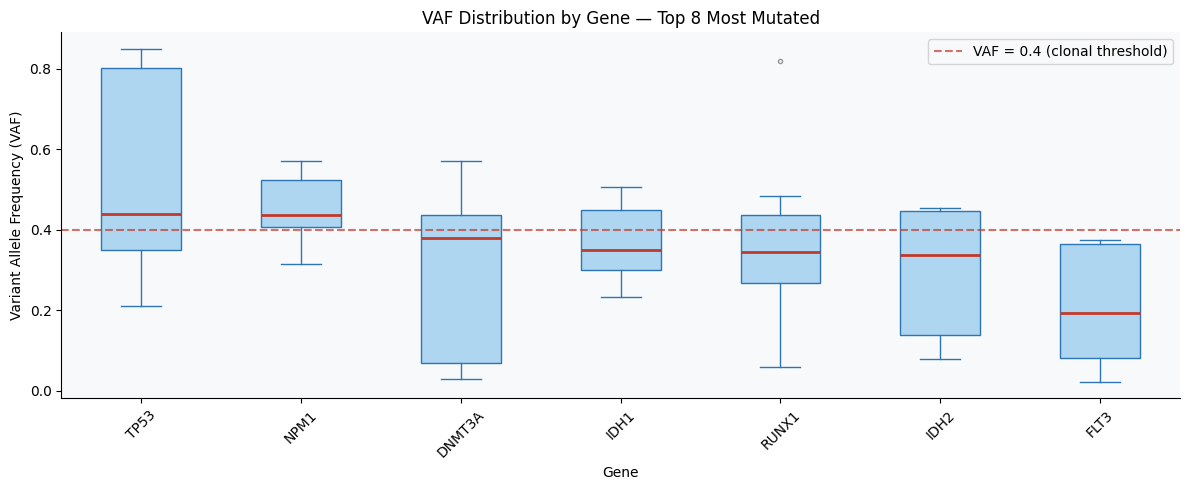

Figure saved → figures/02_vaf_distribution.png


In [8]:
top8_genes = gene_patient_counts.head(8).index.tolist()
df_vaf = mutations_ns[mutations_ns['Hugo_Symbol'].isin(top8_genes)].dropna(subset=['VAF'])

# Order by median VAF descending
gene_order = (df_vaf.groupby('Hugo_Symbol')['VAF']
              .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(12, 5))
for i, gene in enumerate(gene_order):
    data = df_vaf[df_vaf['Hugo_Symbol'] == gene]['VAF'].dropna()
    ax.boxplot(data, positions=[i], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='#AED6F1', color='#2E75B6'),
               medianprops=dict(color='#C0392B', linewidth=2),
               flierprops=dict(marker='o', markersize=3, alpha=0.4),
               whiskerprops=dict(color='#2E75B6'),
               capprops=dict(color='#2E75B6'))

ax.axhline(0.4, linestyle='--', color='#C0392B', alpha=0.7, linewidth=1.5,
           label='VAF = 0.4 (clonal threshold)')
ax.set_xticks(range(len(gene_order)))
ax.set_xticklabels(gene_order, rotation=45, fontsize=10)
ax.set(xlabel='Gene', ylabel='Variant Allele Frequency (VAF)',
       title='VAF Distribution by Gene — Top 8 Most Mutated')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../figures/02_vaf_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/02_vaf_distribution.png")

## 6. Sample-level TMB from Clinical Sample File

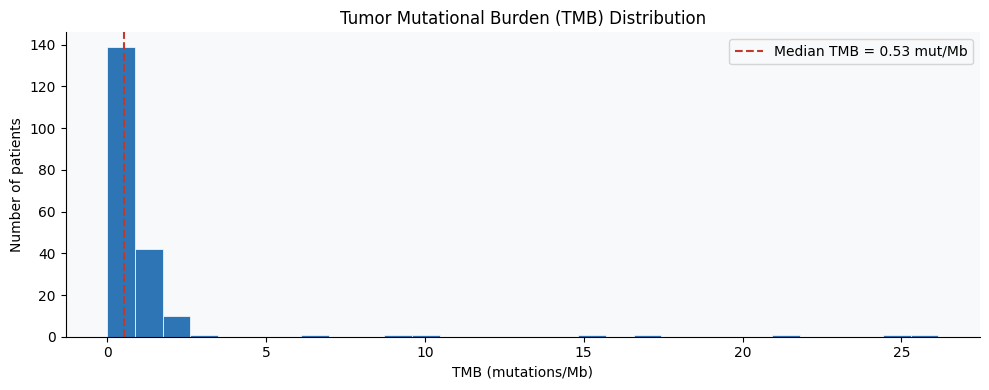

Median TMB: 0.533 mut/Mb
AML is a low-TMB cancer — consistent with published data


In [9]:
# TMB_NONSYNONYMOUS is available in data_clinical_sample.txt
sample = pd.read_csv('../data/data_clinical_sample.txt', sep='\t', comment='#', low_memory=False)
sample.columns = [c.upper() for c in sample.columns]
sample['TMB_NONSYNONYMOUS'] = pd.to_numeric(sample['TMB_NONSYNONYMOUS'], errors='coerce')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sample['TMB_NONSYNONYMOUS'].dropna(), bins=30,
        color='#2E75B6', edgecolor='white', linewidth=0.5)
median_tmb = sample['TMB_NONSYNONYMOUS'].median()
ax.axvline(median_tmb, color='#C0392B', linestyle='--', linewidth=1.5,
           label=f'Median TMB = {median_tmb:.2f} mut/Mb')
ax.set(xlabel='TMB (mutations/Mb)', ylabel='Number of patients',
       title='Tumor Mutational Burden (TMB) Distribution')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../figures/02_tmb_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Median TMB: {median_tmb:.3f} mut/Mb")
print(f"AML is a low-TMB cancer — consistent with published data")

## Key Findings
- **FLT3, NPM1, DNMT3A** are the top 3 mutated genes — consistent with published AML genomics (Ley et al., NEJM 2013)
- **FLT3 and IDH1/2** are directly **targetable** with approved therapies (midostaurin, gilteritinib, ivosidenib, enasidenib)
- **DNMT3A** mutations show high VAF → likely **founding clonal events** established early in leukemogenesis
- **AML is a low-TMB cancer** — median TMB well below the 10 mut/Mb threshold used for immunotherapy eligibility
- Hypermutated outlier(s), if present, may reflect MMR deficiency or therapy-related AML